<a href="https://colab.research.google.com/github/nemo10-boop/WUEKM/blob/main/QCQ_CNN_Classical_Baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision scikit-image matplotlib seaborn

import os, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from scipy.ndimage import gaussian_filter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
IMG_SIZE   = 28
BATCH_SIZE = 4
EPOCHS     = 100
LR         = 1e-3
NUM_WORKERS = 2

print("✅ Config ready")
print(f"   Image size : {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Epochs     : {EPOCHS}")
print(f"   LR         : {LR}")

✅ Config ready
   Image size : 28x28
   Batch size : 4
   Epochs     : 100
   LR         : 0.001


In [3]:
def filter_binary(dataset, class_a, class_b, max_per_class=None):
    targets = np.array(dataset.targets)
    idx_a   = np.where(targets == class_a)[0]
    idx_b   = np.where(targets == class_b)[0]

    if max_per_class:
        idx_a = idx_a[:max_per_class]
        idx_b = idx_b[:max_per_class]

    indices = np.concatenate([idx_a, idx_b])
    np.random.shuffle(indices)

    new_targets = targets.copy()
    new_targets[targets == class_a] = 0
    new_targets[targets == class_b] = 1
    dataset.targets = new_targets.tolist()

    return Subset(dataset, indices)


def split_dataset(dataset, train_n, val_n, test_n):
    total    = len(dataset)
    leftover = total - train_n - val_n - test_n
    train_ds, val_ds, test_ds, _ = random_split(
        dataset,
        [train_n, val_n, test_n, leftover],
        generator=torch.Generator().manual_seed(SEED)
    )
    return train_ds, val_ds, test_ds

print("✅ Helper functions ready")

✅ Helper functions ready


In [4]:
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Download
mnist_train_full = datasets.MNIST(root='./data', train=True,  download=True, transform=base_transform)
mnist_test_full  = datasets.MNIST(root='./data', train=False, download=True, transform=base_transform)

# Filter to digits 3 vs 5
mnist_train_bin = filter_binary(mnist_train_full, 3, 5, max_per_class=3125)
mnist_test_bin  = filter_binary(mnist_test_full,  3, 5, max_per_class=500)

# Split
mnist_train, mnist_val, _ = split_dataset(mnist_train_bin, 5000, 1250, 0)

# Loaders
mnist_loaders = {
    'train': DataLoader(mnist_train,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
    'val'  : DataLoader(mnist_val,      batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    'test' : DataLoader(mnist_test_bin, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

print("✅ MNIST ready")
print(f"   Train : {len(mnist_train)}")
print(f"   Val   : {len(mnist_val)}")
print(f"   Test  : {len(mnist_test_bin)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 556kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


✅ MNIST ready
   Train : 5000
   Val   : 1250
   Test  : 1000


In [5]:
fmnist_train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=base_transform)
fmnist_test_full  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=base_transform)

# Class 0 = T-shirt, Class 1 = Trouser
fmnist_train_bin = filter_binary(fmnist_train_full, 0, 1, max_per_class=3125)
fmnist_test_bin  = filter_binary(fmnist_test_full,  0, 1, max_per_class=500)

fmnist_train, fmnist_val, _ = split_dataset(fmnist_train_bin, 5000, 1250, 0)

fmnist_loaders = {
    'train': DataLoader(fmnist_train,    batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
    'val'  : DataLoader(fmnist_val,      batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    'test' : DataLoader(fmnist_test_bin, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

print("✅ Fashion-MNIST ready")
print(f"   Train : {len(fmnist_train)}")
print(f"   Val   : {len(fmnist_val)}")
print(f"   Test  : {len(fmnist_test_bin)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.94MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.3MB/s]

✅ Fashion-MNIST ready
   Train : 5000
   Val   : 1250
   Test  : 1000


In [6]:
MRI_DIR = './data/mri'
MRI_ZIP = 'brain_tumor_mri.zip'

# Download
if not os.path.exists(MRI_ZIP):
    !wget -O brain_tumor_mri.zip \
        "https://github.com/sartajbhuvaji/brain-tumor-classification-dataset/archive/refs/heads/master.zip"
    print("✅ Downloaded")
else:
    print("✅ Already downloaded — skipping")

# Extract
if not os.path.exists(MRI_DIR):
    os.makedirs(MRI_DIR, exist_ok=True)
    !unzip -q brain_tumor_mri.zip -d {MRI_DIR}
    print("✅ Extracted")
else:
    print("✅ Already extracted — skipping")

# Show folder structure
for p in sorted(Path(MRI_DIR).rglob('*'))[:20]:
    print(p)

--2026-05-18 05:29:54--  https://github.com/sartajbhuvaji/brain-tumor-classification-dataset/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet/zip/refs/heads/master [following]
--2026-05-18 05:29:54--  https://codeload.github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.116.9
Connecting to codeload.github.com (codeload.github.com)|140.82.116.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘brain_tumor_mri.zip’

brain_tumor_mri.zip     [              <=>   ]  86.97M  31.2MB/s    in 2.8s    

2026-05-18 05:29:57 (31.2 MB/s) - ‘brain_tumor_mri.zip’ saved [91198591]

✅ Downloaded
✅ Extracted
data/mr

In [7]:
class MRIBinaryDataset(Dataset):
    BENIGN_FOLDERS    = {'notumor', 'no_tumor', 'no tumor'}
    MALIGNANT_FOLDERS = {'glioma', 'meningioma', 'pituitary'}

    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []

        for img_path in Path(root_dir).rglob('*.jpg'):
            folder = img_path.parent.name.lower().replace('_', ' ').replace('-', ' ')
            if any(b in folder for b in self.BENIGN_FOLDERS):
                self.samples.append((str(img_path), 0))
            elif any(m in folder for m in self.MALIGNANT_FOLDERS):
                self.samples.append((str(img_path), 1))

        for img_path in Path(root_dir).rglob('*.png'):
            folder = img_path.parent.name.lower()
            if any(b in folder for b in self.BENIGN_FOLDERS):
                self.samples.append((str(img_path), 0))
            elif any(m in folder for m in self.MALIGNANT_FOLDERS):
                self.samples.append((str(img_path), 1))

        np.random.shuffle(self.samples)
        labels = [s[1] for s in self.samples]
        print(f"✅ MRI total   : {len(self.samples)}")
        print(f"   Benign (0)  : {labels.count(0)}")
        print(f"   Malignant(1): {labels.count(1)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('L')
        if self.transform:
            img = self.transform(img)
        return img, label


mri_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

mri_full = MRIBinaryDataset(MRI_DIR, transform=mri_transform)

mri_train, mri_val, mri_test = split_dataset(mri_full, 2089, 653, 523)

mri_loaders = {
    'train': DataLoader(mri_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
    'val'  : DataLoader(mri_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    'test' : DataLoader(mri_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

print(f"   Train : {len(mri_train)}")
print(f"   Val   : {len(mri_val)}")
print(f"   Test  : {len(mri_test)}")

✅ MRI total   : 3264
   Benign (0)  : 500
   Malignant(1): 2764
   Train : 2089
   Val   : 653
   Test  : 522


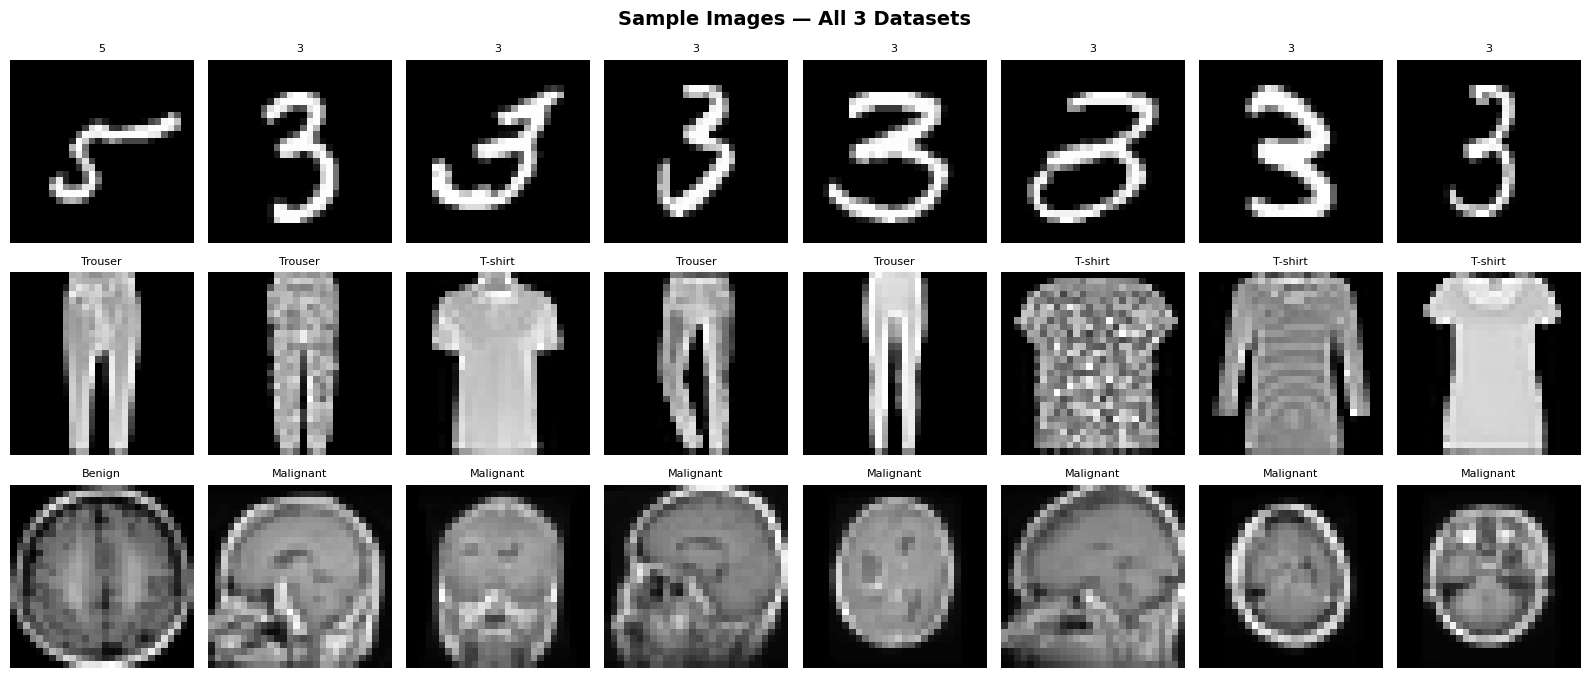

✅ Saved dataset_samples.png


In [8]:
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle('Sample Images — All 3 Datasets', fontsize=14, fontweight='bold')

dataset_info = [
    (mnist_train,  'MNIST 3 vs 5',              ['3', '5']),
    (fmnist_train, 'F-MNIST T-shirt vs Trouser', ['T-shirt', 'Trouser']),
    (mri_train,    'MRI Benign vs Malignant',    ['Benign', 'Malignant']),
]

for row, (ds, title, class_names) in enumerate(dataset_info):
    axes[row, 0].set_ylabel(title, fontsize=9)
    count = 0
    for img, label in ds:
        if count >= 8:
            break
        axes[row, count].imshow(img.squeeze().numpy(), cmap='gray')
        axes[row, count].set_title(class_names[label], fontsize=8)
        axes[row, count].axis('off')
        count += 1

plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=120)
plt.show()
print("✅ Saved dataset_samples.png")

In [9]:
class ClassicalCNN(nn.Module):
    def __init__(self, in_channels=1, img_size=28):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 28 → 14

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                          # 14 → 7
        )

        with torch.no_grad():
            dummy     = torch.zeros(1, in_channels, img_size, img_size)
            flat_size = self.conv_block(dummy).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.classifier(self.conv_block(x))


# Quick check
model_test   = ClassicalCNN().to(DEVICE)
total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
dummy_out    = model_test(torch.randn(4, 1, 28, 28).to(DEVICE))

print(model_test)
print(f"\n✅ Parameters : {total_params:,}")
print(f"✅ Output shape: {tuple(dummy_out.shape)}")

ClassicalCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

✅ Parameters : 105,377
✅ Output shape: (4, 1)


In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds       = (torch.sigmoid(outputs) >= 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.float().unsqueeze(1).to(DEVICE)

        outputs     = model(imgs)
        loss        = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds       = (torch.sigmoid(outputs) >= 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


def train_model(name, loaders):
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")

    model     = ClassicalCNN().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=7, factor=0.5)

    history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state   = None
    stagnant     = 0
    patience     = 15

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(model, loaders['train'], optimizer, criterion)
        va_loss, va_acc = evaluate(model, loaders['val'], criterion)

        history['train_loss'].append(tr_loss)
        history['val_loss'  ].append(va_loss)
        history['train_acc' ].append(tr_acc)
        history['val_acc'   ].append(va_acc)

        scheduler.step(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stagnant     = 0
        else:
            stagnant += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS} | "
                  f"train {tr_acc*100:.2f}% loss {tr_loss:.4f} | "
                  f"val {va_acc*100:.2f}% loss {va_loss:.4f}")

        if stagnant >= patience:
            print(f"  ⏹ Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"\n  ✅ Best val accuracy: {best_val_acc*100:.2f}%")
    return model, history

print("✅ Training functions ready")

✅ Training functions ready


In [12]:
fmnist_model, fmnist_history = train_model('Fashion-MNIST (T-shirt vs Trouser)', fmnist_loaders)
torch.save(fmnist_model.state_dict(), 'cnn_fmnist.pt')
print("Saved → cnn_fmnist.pt")


  Training: Fashion-MNIST (T-shirt vs Trouser)
  Epoch   1/100 | train 98.04% loss 0.0584 | val 99.36% loss 0.0284
  Epoch  10/100 | train 99.90% loss 0.0043 | val 99.36% loss 0.0329
  ⏹ Early stop at epoch 19

  ✅ Best val accuracy: 99.52%
Saved → cnn_fmnist.pt


Validation accuracy stopped improving after epoch 4 or 5, and after 15 epochs of no improvement it stopped at epoch 19–20.


In [13]:
mnist_model, mnist_history = train_model('MNIST (3 vs 5)', mnist_loaders)
torch.save(mnist_model.state_dict(), 'cnn_mnist.pt')
print("Saved → cnn_mnist.pt")


  Training: MNIST (3 vs 5)
  Epoch   1/100 | train 97.14% loss 0.0781 | val 98.64% loss 0.0379
  Epoch  10/100 | train 99.92% loss 0.0049 | val 99.44% loss 0.0235
  Epoch  20/100 | train 99.98% loss 0.0006 | val 99.36% loss 0.0452
  ⏹ Early stop at epoch 25

  ✅ Best val accuracy: 99.44%
Saved → cnn_mnist.pt


Same here.

In [14]:
mri_model, mri_history = train_model('MRI Brain Tumor', mri_loaders)
torch.save(mri_model.state_dict(), 'cnn_mri.pt')
print("Saved → cnn_mri.pt")


  Training: MRI Brain Tumor
  Epoch   1/100 | train 84.92% loss 0.3514 | val 85.45% loss 0.2678
  Epoch  10/100 | train 96.79% loss 0.0772 | val 94.95% loss 0.1812
  Epoch  20/100 | train 98.99% loss 0.0310 | val 95.87% loss 0.1811
  Epoch  30/100 | train 99.71% loss 0.0108 | val 95.25% loss 0.3026
  ⏹ Early stop at epoch 38

  ✅ Best val accuracy: 96.17%
Saved → cnn_mri.pt


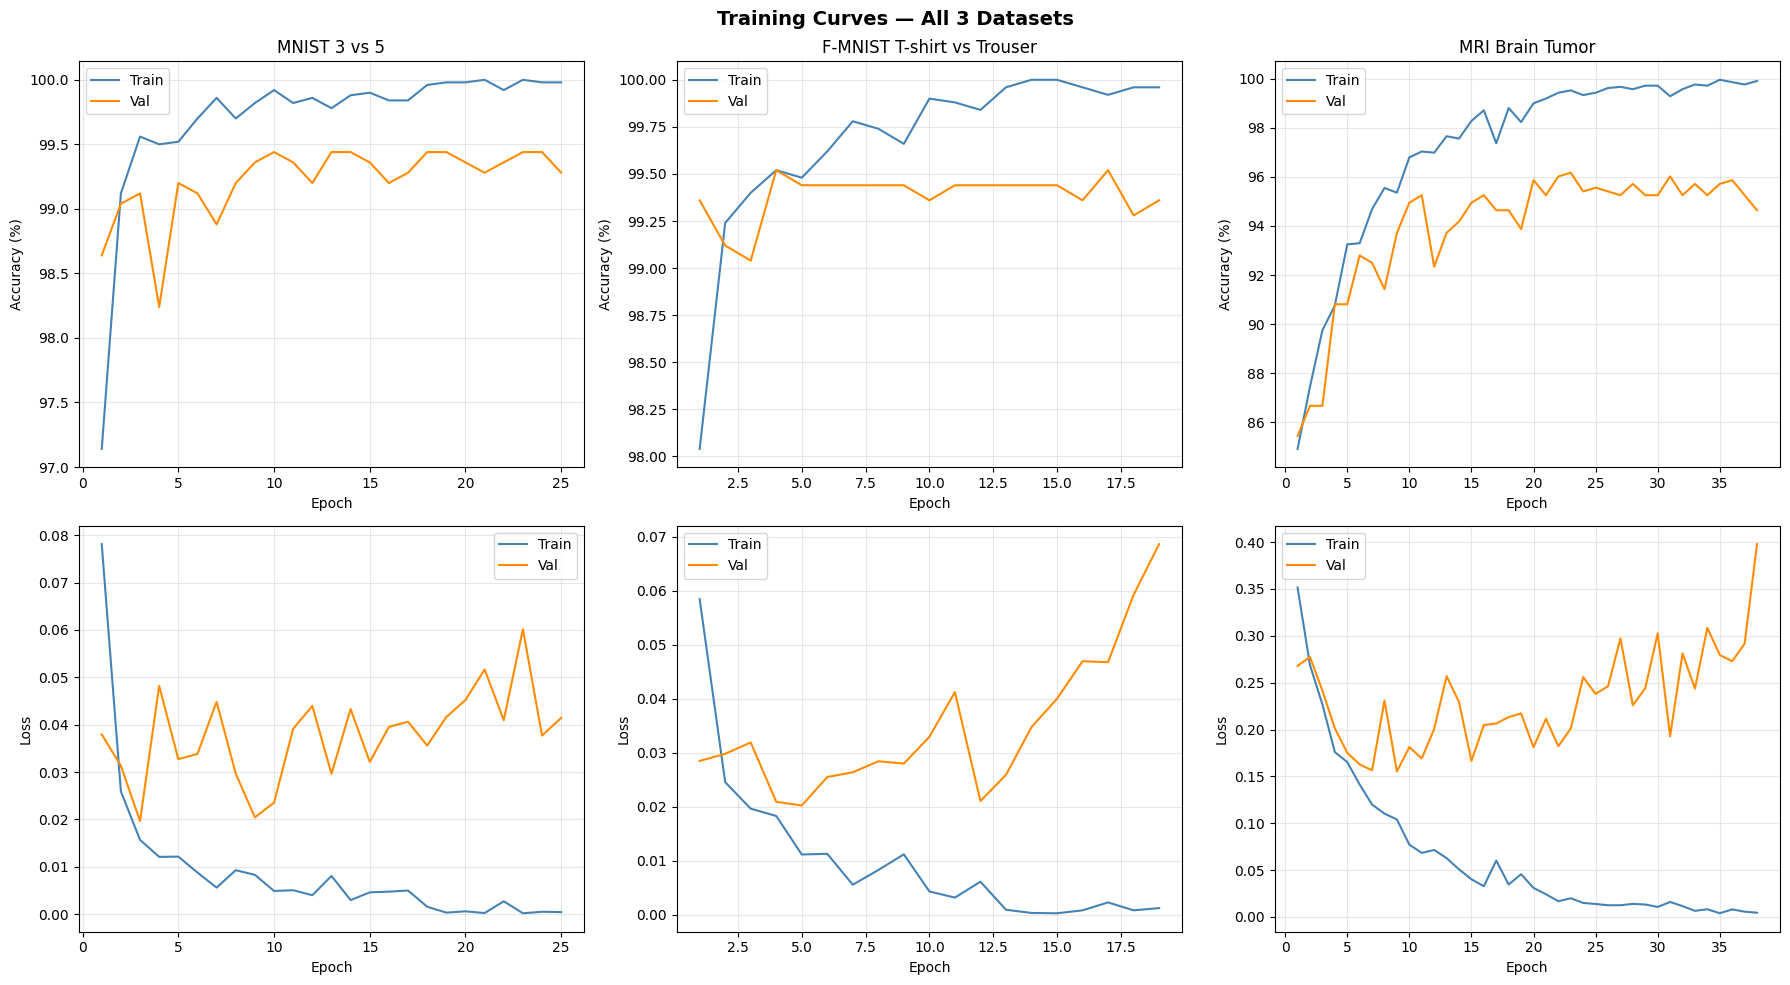

✅ Saved training_curves.png


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Curves — All 3 Datasets', fontsize=14, fontweight='bold')

all_histories = [
    (mnist_history,  'MNIST 3 vs 5'),
    (fmnist_history, 'F-MNIST T-shirt vs Trouser'),
    (mri_history,    'MRI Brain Tumor'),
]

for col, (hist, name) in enumerate(all_histories):
    ep = range(1, len(hist['train_acc']) + 1)

    # Accuracy
    axes[0, col].plot(ep, [v*100 for v in hist['train_acc']], label='Train', color='steelblue')
    axes[0, col].plot(ep, [v*100 for v in hist['val_acc']],   label='Val',   color='darkorange')
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel('Accuracy (%)')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].legend()
    axes[0, col].grid(alpha=0.3)

    # Loss
    axes[1, col].plot(ep, hist['train_loss'], label='Train', color='steelblue')
    axes[1, col].plot(ep, hist['val_loss'],   label='Val',   color='darkorange')
    axes[1, col].set_ylabel('Loss')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].legend()
    axes[1, col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()
print("✅ Saved training_curves.png")

In [16]:
def add_gaussian_noise(tensor, std=0.1):
    noise = torch.randn_like(tensor) * std
    return torch.clamp(tensor + noise, -1.0, 1.0)

def add_salt_pepper_noise(tensor, prob=0.05):
    noisy = tensor.clone()
    mask  = torch.rand_like(tensor)
    noisy[mask < prob / 2]                      = -1.0
    noisy[(mask >= prob / 2) & (mask < prob)]   =  1.0
    return noisy

def add_gaussian_blur(tensor, sigma=1.0):
    np_img  = tensor.numpy()
    blurred = np.stack([
        gaussian_filter(img, sigma=[0, sigma, sigma])
        for img in np_img
    ])
    return torch.from_numpy(blurred)

@torch.no_grad()
def test_with_noise(model, loader, noise_fn, noise_params):
    results = []
    model.eval()
    for param in noise_params:
        correct, total = 0, 0
        for imgs, labels in loader:
            imgs_noisy = noise_fn(imgs, param).to(DEVICE)
            labels     = labels.float().unsqueeze(1).to(DEVICE)
            outputs    = model(imgs_noisy)
            preds      = (torch.sigmoid(outputs) >= 0.5).float()
            correct   += (preds == labels).sum().item()
            total     += imgs.size(0)
        results.append((param, 100.0 * correct / total))
    return results

print("✅ Noise functions ready")

✅ Noise functions ready


In [17]:
gaussian_stds = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
sp_probs      = [0.00, 0.01, 0.03, 0.05, 0.10, 0.15]
blur_sigmas   = [0.0,  0.5,  1.0,  1.5,  2.0,  2.5 ]

datasets_to_test = {
    'MNIST'  : (mnist_model,  mnist_loaders['test']),
    'F-MNIST': (fmnist_model, fmnist_loaders['test']),
    'MRI'    : (mri_model,    mri_loaders['test']),
}

noise_results = {}

for ds_name, (model, loader) in datasets_to_test.items():
    print(f"\nTesting {ds_name}...")
    model.to(DEVICE)
    noise_results.setdefault('Gaussian',      {})[ds_name] = test_with_noise(model, loader, add_gaussian_noise,    gaussian_stds)
    noise_results.setdefault('Salt & Pepper', {})[ds_name] = test_with_noise(model, loader, add_salt_pepper_noise, sp_probs)
    noise_results.setdefault('Gaussian Blur', {})[ds_name] = test_with_noise(model, loader, add_gaussian_blur,     blur_sigmas)
    print(f"  ✅ Done")

print("\n✅ All noise tests complete")


Testing MNIST...
  ✅ Done

Testing F-MNIST...
  ✅ Done

Testing MRI...
  ✅ Done

✅ All noise tests complete


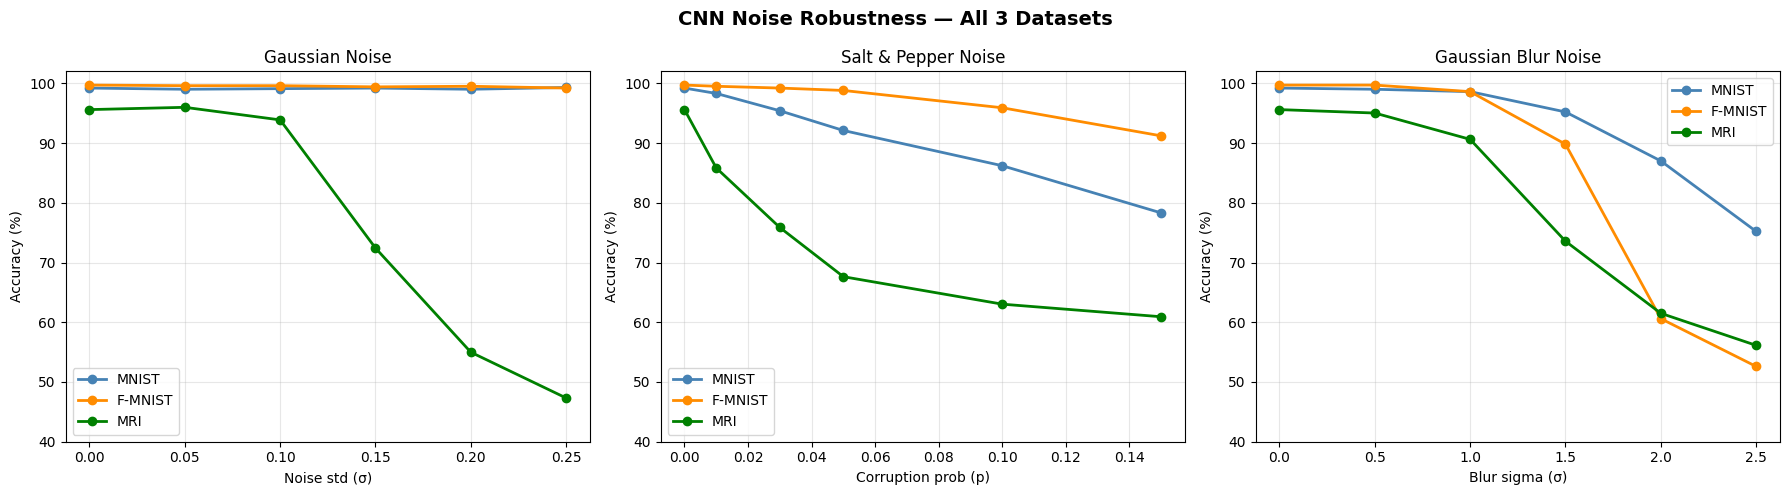

✅ Saved noise_robustness.png


In [18]:
colors   = {'MNIST': 'steelblue', 'F-MNIST': 'darkorange', 'MRI': 'green'}
x_labels = {
    'Gaussian'     : 'Noise std (σ)',
    'Salt & Pepper': 'Corruption prob (p)',
    'Gaussian Blur': 'Blur sigma (σ)'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CNN Noise Robustness — All 3 Datasets', fontsize=14, fontweight='bold')

for col, noise_type in enumerate(['Gaussian', 'Salt & Pepper', 'Gaussian Blur']):
    ax = axes[col]
    for ds_name, results in noise_results[noise_type].items():
        params = [r[0] for r in results]
        accs   = [r[1] for r in results]
        ax.plot(params, accs, marker='o', label=ds_name, color=colors[ds_name], linewidth=2)
    ax.set_title(f'{noise_type} Noise')
    ax.set_xlabel(x_labels[noise_type])
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(40, 102)

plt.tight_layout()
plt.savefig('noise_robustness.png', dpi=120)
plt.show()
print("✅ Saved noise_robustness.png")

In [19]:
criterion = nn.BCEWithLogitsLoss()
results_clean = {}

for ds_name, (model, loader) in datasets_to_test.items():
    model.to(DEVICE)
    _, acc = evaluate(model, loader, criterion)
    results_clean[ds_name] = acc * 100

paper_cnn = {'MNIST': 98.79, 'F-MNIST': 99.19, 'MRI': 89.43}

print(f"\n{'='*55}")
print(f"  FINAL RESULTS vs PAPER (Table 1)")
print(f"{'='*55}")
print(f"{'Dataset':<12} {'Our CNN':>10} {'Paper CNN':>12} {'Diff':>8}")
print("-"*45)
for ds in ['MNIST', 'F-MNIST', 'MRI']:
    our   = results_clean[ds]
    paper = paper_cnn[ds]
    print(f"{ds:<12} {our:>9.2f}%  {paper:>10.2f}%  {our-paper:>+7.2f}%")
print("="*55)


  FINAL RESULTS vs PAPER (Table 1)
Dataset         Our CNN    Paper CNN     Diff
---------------------------------------------
MNIST            99.20%       98.79%    +0.41%
F-MNIST          99.70%       99.19%    +0.51%
MRI              95.59%       89.43%    +6.16%


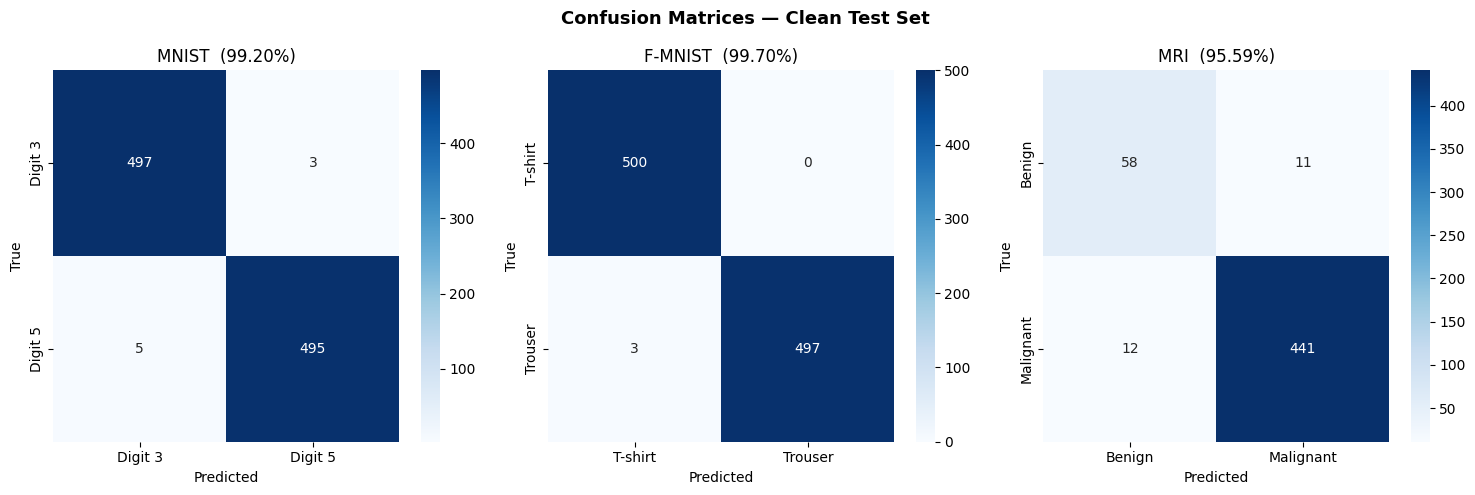

✅ Saved confusion_matrices.png


In [20]:
class_labels_map = {
    'MNIST'  : ['Digit 3',  'Digit 5'],
    'F-MNIST': ['T-shirt',  'Trouser'],
    'MRI'    : ['Benign',   'Malignant'],
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices — Clean Test Set', fontsize=13, fontweight='bold')

for col, (ds_name, (model, loader)) in enumerate(datasets_to_test.items()):
    model.to(DEVICE).eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(DEVICE))
            preds   = (torch.sigmoid(outputs) >= 0.5).long().cpu().squeeze()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels_map[ds_name],
                yticklabels=class_labels_map[ds_name],
                ax=axes[col])
    axes[col].set_title(f'{ds_name}  ({results_clean[ds_name]:.2f}%)')
    axes[col].set_xlabel('Predicted')
    axes[col].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()
print("✅ Saved confusion_matrices.png")

In [21]:
for ds_name, (model, loader) in datasets_to_test.items():
    model.to(DEVICE).eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(DEVICE))
            preds   = (torch.sigmoid(outputs) >= 0.5).long().cpu().squeeze()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    print(f"\n{'='*45}")
    print(f"  {ds_name}")
    print('='*45)
    print(classification_report(all_labels, all_preds,
                                 target_names=class_labels_map[ds_name]))


  MNIST
              precision    recall  f1-score   support

     Digit 3       0.99      0.99      0.99       500
     Digit 5       0.99      0.99      0.99       500

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


  F-MNIST
              precision    recall  f1-score   support

     T-shirt       0.99      1.00      1.00       500
     Trouser       1.00      0.99      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


  MRI
              precision    recall  f1-score   support

      Benign       0.83      0.84      0.83        69
   Malignant       0.98      0.97      0.97       453

    accuracy                           0.96       522
   macro avg       0.90      0.91      0.90       522
weighted avg       0.96      0.96      0.96    